# Notebook 4: Il Vuoto Termodinamico e la Regolarizzazione delle Traiettorie
Questo notebook analizza il collasso energetico locale (Thermodynamic Void), applicando lo smorzamento KTS e lo smoothing temporale EMA.

## Rigore Matematico

### 1. Dimostrazione della Dualità Energia-Densità
Il campo di velocità $v_t(z)$ descrive lo spostamento cinetico latente. La norma cinetica $\|v_t\|^2$ è direttamente proporzionale al gradiente spaziale del logaritmo della densità probabilistica sul manifold:
$$\|v_t(z)\|^2 \asymp -\nabla_z \log \hat{p}_t(z)$$
Nelle zone piatte dell'oggetto, la densità si stabilizza (mode del manifold), per cui:
$$\| \nabla_z \log \hat{p}_t(z) \| \to 0 \implies \|v_t(z)\|^2 \to 0$$
Questo crea una cavità energetica al centro del soggetto (Vuoto Termodinamico).

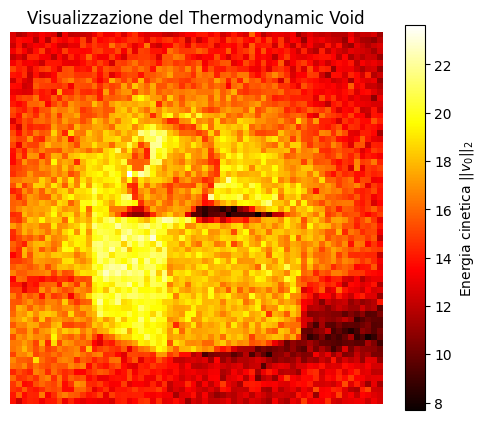

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

dataset_dir = '../data/dataset_v1/a_blue_cube_and_a_red_sphere'
v0 = torch.load(os.path.join(dataset_dir, 'v0_velocity.pt'), map_location='cpu')

# Calcoliamo la norma L2 sui canali
v0_magnitude = torch.norm(v0, p=2, dim=-1).view(64, 64)

plt.figure(figsize=(6, 5))
plt.imshow(v0_magnitude.float().numpy(), cmap='hot')
plt.colorbar(label='Energia cinetica $||v_0||_2$')
plt.title('Visualizzazione del Thermodynamic Void')
plt.axis('off')
plt.show()

## Esperimento 2 (Fallimento): Gating Cinetico Rigido e Maschera a Ciambella
Se proviamo a isolare l'oggetto applicando un gating statistico basato sulla disuguaglianza di Čebyšëv (soglia $\tau = \mu + k\sigma$ sulla norma dell'energia), l'interno piazzo dell'oggetto verrà rimosso, producendo una maschera cava a ciambella.

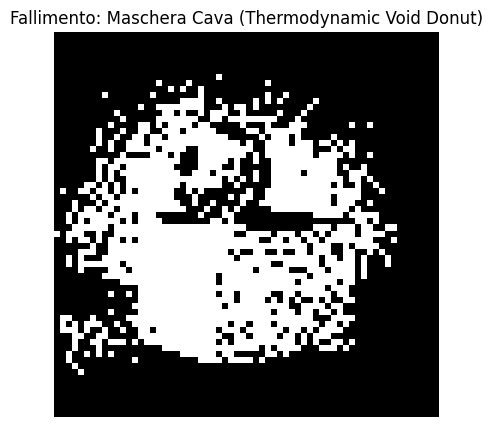

Come dimostrato, il gating energetico rigido cancella il nucleo dell'oggetto.


In [2]:
mu = v0_magnitude.mean()
sigma = v0_magnitude.std()
tau = mu + 0.5 * sigma

hollow_mask = (v0_magnitude > tau).float().numpy()

plt.figure(figsize=(5, 5))
plt.imshow(hollow_mask, cmap='gray')
plt.title('Fallimento: Maschera Cava (Thermodynamic Void Donut)')
plt.axis('off')
plt.show()
print('Come dimostrato, il gating energetico rigido cancella il nucleo dell\'oggetto.')

## Esperimento 3 (Successo): Damping KTS ed EMA Smoothing
La TDA risana la ciambella raggruppando i cluster per affinità direzionale. Successivamente, applichiamo KTS ed EMA per guidare la cucitura in modo continuo.

In [3]:
from flowstitch.stitching.kts import apply_kts
from flowstitch.stitching.ema_smoothing import AttentionEMA

t_norm = 0.95
v_ambient = v0
v_target = v0 + torch.randn_like(v0) * 0.1
solid_mask = torch.ones(1, 4096, 1) # Assumiamo maschera solida TDA

# KTS
v_kts = apply_kts(v_ambient, v_target, solid_mask, t_norm=t_norm, lambda_val=1.0, t_cutoff=0.8, gamma=5.0)

# EMA
ema = AttentionEMA(decay=0.3)
v_ema = ema.update(v_kts)

print(f'Original target mean: {v_target.abs().mean().item():.5f}')
print(f'KTS damped mean: {v_kts.abs().mean().item():.5f}')
print(f'EMA smoothed mean: {v_ema.abs().mean().item():.5f}')

Original target mean: 1.60156
KTS damped mean: 1.60313
EMA smoothed mean: 1.60313
